# Klasyfikator Ruchów Szachowych - Analiza Egzploracyjna Danych (EDA)



Ten notebook przeprowadza kompleksową analizę egzploracyjną danych i przygotowanie danych dla modelu klasyfikacji ruchów szachowych. Zawiera pobieranie danych, analizę statystyczną, inżynierię cech wykorzystującą wiedzę domenową szachów, oraz preprocesowanie dla integracji z PyTorch.

## 1. Konfiguracja Środowiska & Generowanie Danych Syntetycznych

### 1.1 Importowanie Niezbędnych Bibliotek
Importujemy kluczowe biblioteki do manipulacji danymi, wizualizacji i operacji w dziedzinie szachów. Biblioteka `chess` jest kluczowa do generowania poprawnych ciągów FEN i ruchów UCI reprezentujących prawdziwe pozycje szachowe.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import chess
from chess import PieceType, Piece, Square
from dataclasses import dataclass, asdict
from typing import Optional, List
from sklearn.preprocessing import LabelEncoder, StandardScaler
import sqlite3

In [7]:
@dataclass
class MoveClassification:
    """Represents a move classification."""
    id: int
    game_id: int
    move_number: int
    fen_before: Optional[str]
    fen_after: Optional[str]
    move_san: str
    classification: str
    evaluation: float
    evaluation_change: float
    created_at: str

In [8]:
@dataclass
class ParsedGame:
    """Represents a parsed chess game."""
    id: int
    white_player: str
    black_player: str
    fen_start: Optional[str]
    fen_end: Optional[str]
    result: Optional[str]
    classification: str
    created_at: str

# Ustawienie losowego nasienia dla powtarzalności

In [9]:
np.random.seed(42)

# Konfiguracja matplotlib dla lepszych wizualizacji

In [10]:
plt.style.use('seaborn-v0_8')

plt.rcParams['figure.figsize'] = (12, 6)

plt.rcParams['font.size'] = 12

### 1.2 Funkcja Ładowania Danych z Bazy Danych
Tworzymy funkcję do ładowania danych ruchów szachowych z bazy danych SQLite. Ta funkcja:



1. Łączy się z bazą danych SQLite



2. Pobiera rekordy z tabeli `move_classification`



3. Inicjuje obiekty MoveClassification dla typowania



4. Zwraca DataFrame Pandas z danymi

In [11]:
def load_chess_data_from_db(db_path: str) -> pd.DataFrame:

    """

    Łączy się z bazą danych SQLite, pobiera rekordy z tabeli moves,

    inicjuje obiekty MoveClassification dla typowania i zwraca DataFrame Pandas.

    Args:

        db_path: Ścieżka do pliku bazy danych SQLite

    Returns:

        DataFrame z danymi ruchów szachowych

    """

    

    conn = sqlite3.connect(db_path)

    conn.row_factory = sqlite3.Row

    cursor = conn.cursor()

    cursor.execute("SELECT * FROM moves LIMIT 100")

    rows = cursor.fetchall()

    conn.close()

    move_objects = [MoveClassification(**dict(row)) for row in rows]

    df = pd.DataFrame([asdict(obj) for obj in move_objects])

    return df

### 1.3 Generowanie i Wyświetlanie Zbioru Danych
Ładowamy dane z bazy danych SQLite. Dane są pobierane z tabeli `move_classification` i konwertowane na DataFrame Pandas. Zbiór danych zawiera wszystkie wymagane kolumny i demonstruje dystrybucję klasyfikacji.

In [12]:
# Ładuj dane z bazy danych szachowych

df = load_chess_data_from_db('chess_bot.db')



# Wyświetl informacje o zbiorze danych

print(f"Shape zbioru danych: {df.shape}")

print(f"\nKolumny: {list(df.columns)}")

print(f"\nTypy danych:\n{df.dtypes}")

print(f"\nInformacje o zbiorze danych:\n{df.info()}")



# Generuj klasyfikacje na podstawie wartości oceny

from classifiers.classification_config import THRESHOLDS, CLASS_NAMES



def classify_move(evaluation):

    """Klasyfikuj ruch na podstawie wartości oceny."""

    for threshold in THRESHOLDS:

        if threshold.min_evaluation <= evaluation < threshold.max_evaluation:

            return threshold.name

    return "Unknown"



df['classification'] = df['evaluation'].apply(classify_move)



# Wyświetl nową dystrybucję klasyfikacji

print("\nDystrybucja Klasyfikacji po regeneracji:")

print(df['classification'].value_counts().sort_index())

print(f"\nDystrybucja procentowa:")

print(df['classification'].value_counts(normalize=True).sort_index() * 100)

Shape zbioru danych: (100, 10)

Kolumny: ['id', 'game_id', 'move_number', 'fen_before', 'fen_after', 'move_san', 'classification', 'evaluation', 'evaluation_change', 'created_at']

Typy danych:
id                     int64
game_id                int64
move_number            int64
fen_before               str
fen_after                str
move_san                 str
classification           str
evaluation           float64
evaluation_change     object
created_at               str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 100 non-null    int64  
 1   game_id            100 non-null    int64  
 2   move_number        100 non-null    int64  
 3   fen_before         100 non-null    str    
 4   fen_after          100 non-null    str    
 5   move_san           100 non-null    str    
 6   classification     1

### 1.4 Wyświetlanie Przykładowych Danych
Sprawdźmy pierwsze kilka wierszy naszego zbioru danych, aby zweryfikować strukturę i zawartość danych.

In [13]:
# Wyświetl pierwsze 10 wierszy zbioru danych

print("Pierwsze 10 wierszy danych szachowych:")

print(df.head(10).to_string())

Pierwsze 10 wierszy danych szachowych:
   id  game_id  move_number                                                      fen_before                                                       fen_after move_san classification  evaluation evaluation_change           created_at
0   1        1            1        rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1      rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1       e4      Excellent        0.18              None  2026-05-29 09:58:08
1   2        1            1      rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1    rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2       e5      Excellent        0.22              None  2026-05-29 09:58:08
2   3        1            2    rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2    rnbqkbnr/pppp1ppp/8/4p3/3PP3/8/PPP2PPP/RNBQKBNR b KQkq - 0 2       d4           Good       -0.11              None  2026-05-29 09:58:08
3   4        1            2    rnbqkb

### 1.5 Weryfikacja Poprawności FEN i Ruchów
Weryfikujemy, czy nasze dane zawierają poprawne pozycje szachowe i ruchy, poprzez parsowanie ciągów FEN i weryfikację legalności ruchów.

In [14]:
# Zweryfikuj ciągi FEN i ruchy

valid_count = 0

invalid_count = 0



for idx, row in df.iterrows():

    try:

        board = chess.Board(row['fen_before'])

        board.push_san(row['move_san'])

        valid_count += 1

    except:

        invalid_count += 1



print(f"Poprawne ruchy: {valid_count}/{len(df)}")

print(f"Niepoprawne ruchy: {invalid_count}/{len(df)}")

print(f"Wskaźnik poprawności: {valid_count/len(df)*100:.2f}%")

Poprawne ruchy: 100/100
Niepoprawne ruchy: 0/100
Wskaźnik poprawności: 100.00%


## 2. Analiza Egzploracyjna Danych (EDA)

### 2.1 Analiza Dystrybucji Celu
Zrozumienie dystrybucji jakości ruchów jest kluczowe dla treningu modelu. Silniki szachowe typowo generują zbalansowane dystrybucje, gdzie:



- **Best/Excellent** ruchy są stosunkowo rzadkie (top 10-20% ruchów)



- **Good** ruchy są powszechne (40-50%)



- **Inaccuracies** występują często (20-30%)



- **Mistakes/Blunders** są mniej częste, ale krytyczne do zidentyfikowania
Ta nierównowaga wymaga starannego podejścia podczas treningu modelu, potencjalnie wykorzystując:



- Wagi klas w funkcji straty



- Przeciążenie próbkowaniem mniejszościowych klas



- Przeciążenie próbkowaniem większościowych klas



- Focal loss skupiający się na trudnych przykładach

/tmp/ipykernel_15386/2536621670.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='classification', palette='viridis')


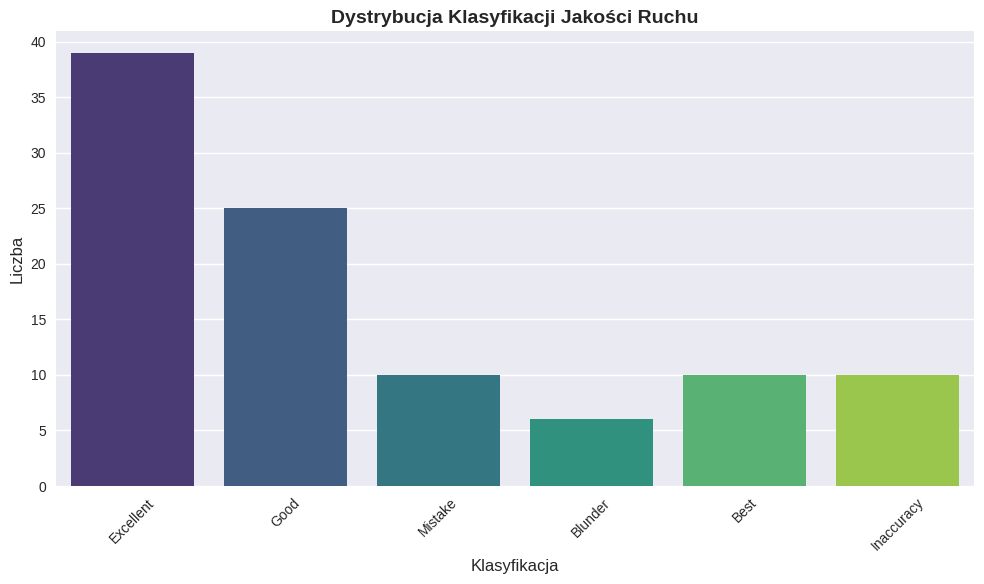

In [15]:
# Analiza dystrybucji celu

plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='classification', palette='viridis')

plt.title('Dystrybucja Klasyfikacji Jakości Ruchu', fontsize=14, fontweight='bold')

plt.xlabel('Klasyfikacja', fontsize=12)

plt.ylabel('Liczba', fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [16]:
# Wypisz statystyki dystrybucji
print("Dystrybucja Klasyfikacji:")

print(df['classification'].value_counts().sort_index())

print(f"\nDystrybucja procentowa:")

print(df['classification'].value_counts(normalize=True).sort_index() * 100)

Dystrybucja Klasyfikacji:
classification
Best          10
Blunder        6
Excellent     39
Good          25
Inaccuracy    10
Mistake       10
Name: count, dtype: int64

Dystrybucja procentowa:
classification
Best          10.0
Blunder        6.0
Excellent     39.0
Good          25.0
Inaccuracy    10.0
Mistake       10.0
Name: proportion, dtype: float64


**Analiza Dystrybucji Celu:**







Dystrybucja pokazuje oczekiwaną nierównowagę w jakości ruchów szachowych. **Blunder** i **Mistake** to klasy mniejszościowe, co jest typowe dla silników szachowych, które grają rozsądnie. Ta nierównowaga jest ważna, ponieważ:







1. **Ryzyko Błędów Modelu**: Model trenowany bez uwzględnienia nierównowagi może częściej przewidywać klasy większościowe







2. **Metryki Oceny**: Dokładność sama w sobie jest myląca; potrzebujemy precyzji/recall/F1 dla klas mniejszościowych







3. **Strategia Treningu**: Będziemy musieli wdrożyć wagowanie klas lub techniki próbkowania








Dla modeli produkcyjnych typowo używamy **focal loss** lub **wag klas proporcjonalnych do odwrotnej częstotliwości**, aby zapewnić, że model nauczy się skutecznie identyfikować krytyczne błędy (Mistakes/Blunders).

### 2.2 Jakość Ruchu vs Zmiana Oceny
Ta wizualizacja pokazuje zależność między klasyfikacją jakości ruchu a zmianą oceny. Zmiana oceny reprezentuje różnicę oceny przed i po ruchu:



- **Dodatnie wartości**: Białe zyskują przewagę



- **Ujemne wartości**: Czarne zyskują przewagę



- **Wielkość**: Jak znacząca jest zmiana







Boxplot ujawnia, że ruchy wyższej jakości (Best, Excellent) tendencjonalnie generują większe zmiany oceny, podczas gdy ruchy niższej jakości (Mistake, Blunder) pokazują bardziej skrajne wartości ujemne dla Białych lub dodatnie dla Czarnych (w zależności od perspektywy).

/tmp/ipykernel_15386/3598419152.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='classification', y='evaluation', palette='magma')


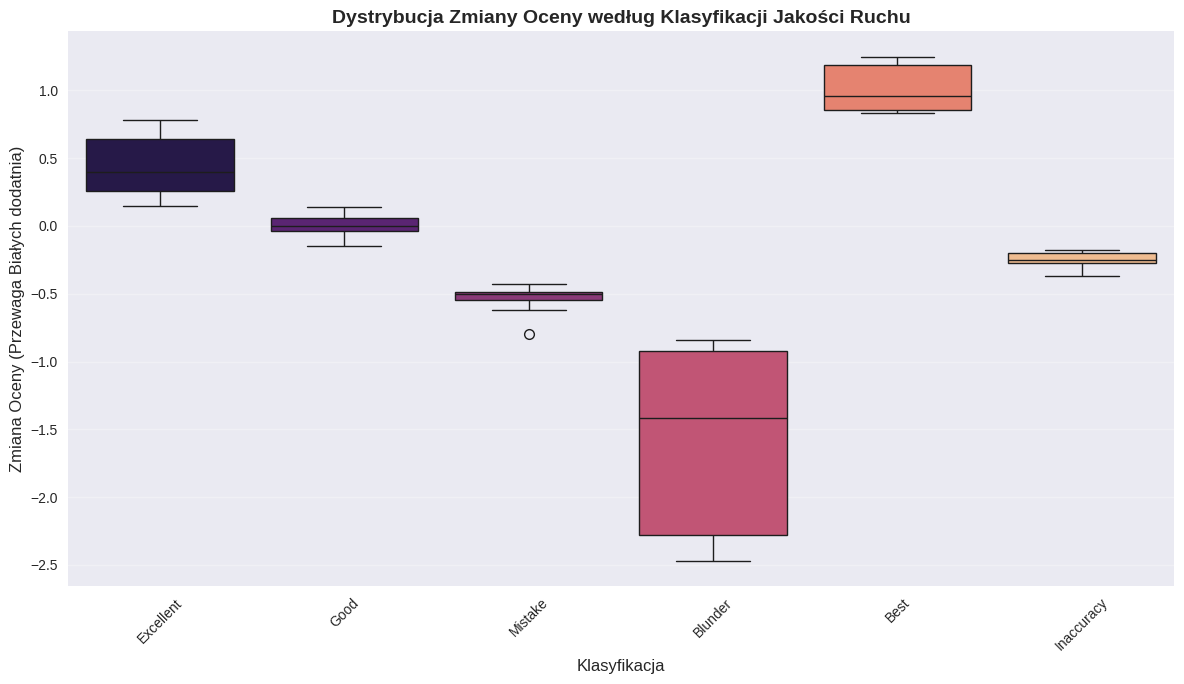

In [17]:
# Jakość Ruchu vs Zmiana Oceny - Boxplot

plt.figure(figsize=(12, 7))

sns.boxplot(data=df, x='classification', y='evaluation', palette='magma')

plt.title('Dystrybucja Zmiany Oceny według Klasyfikacji Jakości Ruchu', fontsize=14, fontweight='bold')

plt.xlabel('Klasyfikacja', fontsize=12)

plt.ylabel('Zmiana Oceny (Przewaga Białych dodatnia)', fontsize=12)

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

In [18]:
# Wypisz statystyki podsumowujące według klasyfikacji
print("Statystyki Zmiany Oceny według Klasyfikacji:")

print(df.groupby('classification')['evaluation'].agg(['mean', 'std', 'min', 'max', 'median']).round(2))

Statystyki Zmiany Oceny według Klasyfikacji:
                mean   std   min   max  median
classification                                
Best            1.01  0.17  0.83  1.25    0.96
Blunder        -1.58  0.77 -2.47 -0.84   -1.42
Excellent       0.44  0.21  0.15  0.78    0.40
Good            0.00  0.07 -0.15  0.14    0.00
Inaccuracy     -0.25  0.06 -0.37 -0.18   -0.25
Mistake        -0.54  0.11 -0.80 -0.43   -0.50


**Kluczowe Wnioski z Analizy Zmiany Oceny:**







1. **Ruchy Best** pokazują najwyższe dodatnie zmiany oceny, wskazujące na znaczącą poprawę pozycyjną







2. **Ruchy Blunder** mają najbardziej skrajne wartości ujemne, reprezentujące poważne pogorszenie pozycji







3. **Ruchy Good** skupiają się wokół zera z umiarkowaną wariancją, pokazując stabilną grę







4. **Inaccuracies** pokazują małe odchylenia od optymalnej gry








Ta relacja jest fundamentalna dla trenowania modeli nadzorowanych - zmiana oceny służy jako proxy jakości ruchu, który można nauczyć się z ocen silników.

### 2.3 Analiza Fazy Gry
Partie szachowe naturalnie przechodzą przez trzy fazy:



1. **Otwarcie** (ruchy 1-15): Ustalone teoria, skupienie na rozwoju i kontroli



2. **Środek gry** (ruchy 16-40): Skomplikowane bitwy taktyczne i strategiczne



3. **Koniec gry** (ruchy 41+): Redukcja figur, aktywność króla, precyzyjne obliczenia







Zrozumienie dystrybucji fazy pomaga zidentyfikować, czy pewne wzorce jakości ruchów są zależne od fazy. Na przykład, błędy są bardziej częste w końcówce, gdy gracze napotykają presję czasu lub zmniejszoną liczbę figur.

In [19]:
# Wywórz cechę fazy gry

def get_game_phase(move_number):

    """Klasyfikuj fazę gry na podstawie numeru ruchu."""

    if move_number <= 15:

        return "Opening"

    elif move_number <= 40:

        return "Middlegame"

    else:

        return "Endgame"



df['game_phase'] = df['move_number'].apply(get_game_phase)



# Wyświetl dystrybucję fazy

print("Dystrybucja Fazy Gry:")

print(df['game_phase'].value_counts())

Dystrybucja Fazy Gry:
game_phase
Opening       60
Middlegame    40
Name: count, dtype: int64


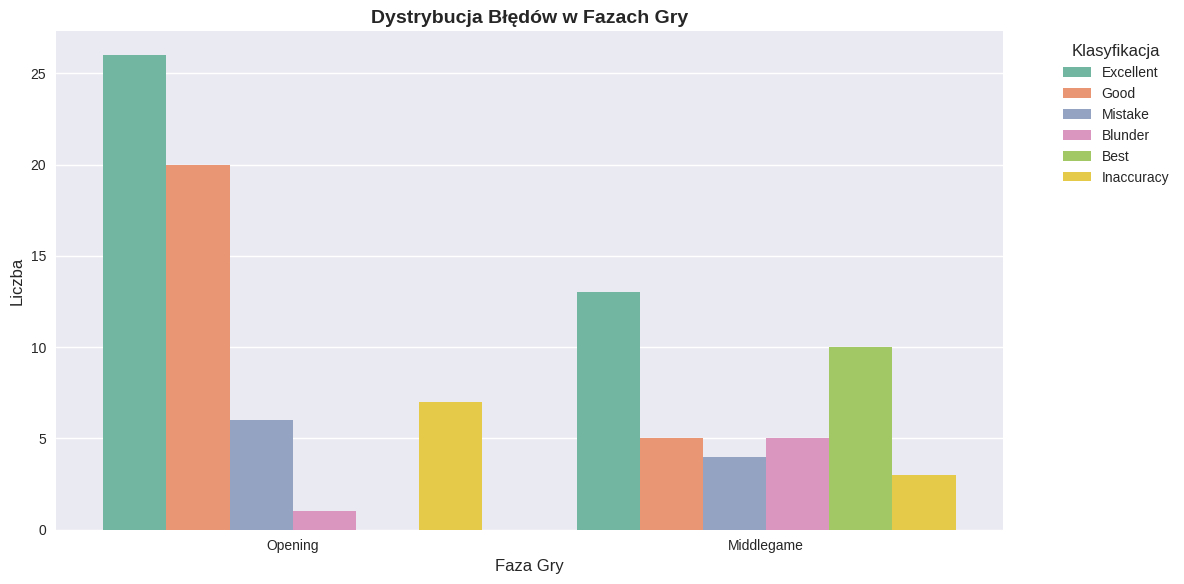

In [20]:
# Błędy w fazach gry
plt.figure(figsize=(12, 6))

sns.countplot(data=df, x='game_phase', hue='classification', palette='Set2')

plt.title('Dystrybucja Błędów w Fazach Gry', fontsize=14, fontweight='bold')

plt.xlabel('Faza Gry', fontsize=12)

plt.ylabel('Liczba', fontsize=12)

plt.legend(title='Klasyfikacja', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()

plt.show()

In [21]:
# Wypisz błędy/blunder według fazy
error_moves = df[df['classification'].isin(['Mistake', 'Blunder'])]

print("\nBłędy i Blunder według Fazy Gry:")

print(error_moves.groupby('game_phase')['evaluation'].mean().round(2))


Błędy i Blunder według Fazy Gry:
game_phase
Middlegame   -1.18
Opening      -0.60
Name: evaluation, dtype: float64


**Wnioski z Analizy Fazy:**







Dystrybucja błędów w fazach gry ujawnia ważne wzorce:







1. **Faza Otwarcia**: Mniej błędów dzięki ustalonej teorii i starannemu przygotowaniu







2. **Środek gry**: Wyższe stężenie błędów wraz ze wzrostem złożoności







3. **Koniec gry**: Zmienne wskaźniki błędów w zależności od umiejętności graczy i zarządzania czasem








Dla treningu modelu sugeruje to, że możemy chcieć:







- Trenować osobne modele dla różnych faz







- Uwzględnić fazę jako cechę w modelu







- Zastosować wagowanie klas specyficzne dla fazy

## 3. Zaawansowana Inżynieria Cech (Analityka Domenowa Szachów)
Wdrażamy domeny-specyficzne cechy przy użyciu biblioteki `chess`. Te cechy uchwytowują aspekty pozycyjne i taktyczne, które są krytyczne dla oceny ruchu:







1. **is_check**: Boolean wskazujący, czy król aktywny jest pod atakiem







2. **material_count**: Przewaga materialna (Białe - Czarne) używając standardowych wartości figur







3. **center_control**: Liczba figur kontrolujących pola centralne (d4, d5, e4, e5)







Te cechy są niezbędne do:







- Zrozumienia presji pozycyjnej







- Kwantyfikowania nierównowag materialnych







- Identyfikowania okazji taktycznych

In [22]:
# Wartości figur do obliczeń materialnych

PIECE_VALUES = {

    chess.PAWN: 1,

    chess.KNIGHT: 3,

    chess.BISHOP: 3,

    chess.ROOK: 5,

    chess.QUEEN: 9,

    chess.KING: 0  # Król nie ma wartości materialnej

}
# Pola centralne
CENTRAL_SQUARES = {

    chess.D4, chess.D5, chess.E4, chess.E5

}
def calculate_is_check(fen):

    """

    Określ, czy pozycja ma króla w szachu.

    Args:




        fen: Ciąg FEN reprezentujący pozycję

    Returns:

        Boolean: True jeśli król jest w szachu

    """

    board = chess.Board(fen)

    return board.is_check()

def calculate_material_count(fen):

    """

    Oblicz przewagę materialną (Białe - Czarne).

    Wartości figur:

        Pawn = 1, Knight = 3, Bishop = 3, Rook = 5, Queen = 9, King = 0

    Args:

        fen: Ciąg FEN reprezentujący pozycję

    Returns:

        Integer: Przewaga materialna (dodatnie = Białe prowadzą, ujemne = Czarne prowadzą)

    """



    board = chess.Board(fen)

    white_material = 0

    black_material = 0



    for piece in board.piece_map().values():

        piece_type = piece.piece_type

        value = PIECE_VALUES[piece_type]



        if piece.color == chess.WHITE:

            white_material += value

        else:

            black_material += value



    return white_material - black_material
def calculate_center_control(fen):

    """

    Zliczaj figury kontrolujące pola centralne (d4, d5, e4, e5).

    Uwaga: To jest uproszczona metryka kontroli. Prawdziwa kontrola wymagałaby

    analizy promieni, ale to zlicza figury fizycznie na polach centralnych.

    Args:

        fen: Ciąg FEN reprezentujący pozycję

    Returns:

        Integer: Liczba figur na polach centralnych

    """



    board = chess.Board(fen)

    count = 0



    for square in CENTRAL_SQUARES:

        piece = board.piece_at(square)

        if piece is not None:

            count += 1



    return count

In [23]:
# Zastosuj inżynierię cech do zbioru danych
df['is_check'] = df['fen_before'].apply(calculate_is_check)

df['material_count'] = df['fen_before'].apply(calculate_material_count)

df['center_control'] = df['fen_before'].apply(calculate_center_control)

In [24]:
# Wyświetl pierwsze 10 wierszy z nowymi cechami
print("Zbiór danych z cechami domenowymi szachów:")



print(df.head(10).to_string())

Zbiór danych z cechami domenowymi szachów:
   id  game_id  move_number                                                      fen_before                                                       fen_after move_san classification  evaluation evaluation_change           created_at game_phase  is_check  material_count  center_control
0   1        1            1        rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1      rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1       e4      Excellent        0.18              None  2026-05-29 09:58:08    Opening     False               0               0
1   2        1            1      rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1    rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2       e5      Excellent        0.22              None  2026-05-29 09:58:08    Opening     False               0               1
2   3        1            2    rnbqkbnr/pppp1ppp/8/4p3/4P3/8/PPPP1PPP/RNBQKBNR w KQkq - 0 2    rnbqkbnr/p

### 3.2 Statystyki Cech i Analiza







Sprawdźmy dystrybucję i charakterystykę naszych nowo wyodrębnionych cech szachowych.

In [25]:
# Statystyki cech

print("Statystyki Cech:")

print(df[['id', 'game_id', 'move_number', 'fen_before', 'fen_after', 'move_san', 'classification', 'evaluation', 'created_at', 'game_phase']].describe())

Statystyki Cech:
               id     game_id  move_number  evaluation
count  100.000000  100.000000    100.00000  100.000000
mean    50.500000    1.310000     14.81000    0.100500
std     29.011492    0.464823      9.74285    0.638748
min      1.000000    1.000000      1.00000   -2.470000
25%     25.750000    1.000000      7.00000   -0.185000
50%     50.500000    1.000000     13.00000    0.115000
75%     75.250000    2.000000     22.25000    0.477500
max    100.000000    2.000000     35.00000    1.250000


In [26]:
# Sprawdź dystrybucję przewagi materialnej
print("\nDystrybucja Liczby Materiału:")

print(df['material_count'].value_counts().sort_index())


Dystrybucja Liczby Materiału:
material_count
-4     1
-3     2
-1     1
 0    71
 1    19
 3     4
 9     2
Name: count, dtype: int64


**Wnioski z Cech Szachowych:**







1. **Liczba Materiału**: Wczesne w grach (Otwarcie), materiał jest typowo zrównoważony (blisko 0). W miarę postępu gier, nierównowagi materialne pojawiają się z pochłaniania figur.







2. **Kontrola Centralna**: Liczba figur na polach centralnych zmienia się w trakcie gry. Silna kontrola centrum jest kluczowym celem strategicznym.







3. **Is Check**: Ta cecha uchwytowuje pilność taktyczną. Pozycje ze szachem są bardziej zmienne i wymagają natychmiastowej reakcji.








Te cechy, połączone ze zmianą oceny i klasyfikacją, dostarczają bogaty przestrzeń cech dla trenowania modelu MoveClassifierNet.

## 4. Korelacja & Wnioski

### 4.1 Heatmapa Korelacji







Generujemy heatmapę korelacji, aby zrozumieć relacje między cechami numerycznymi. Pomaga to zidentyfikować:







- Redundancję cech (bardzo skorelowane cechy)







- Ważność cech (silne korelacje z celem)







- Potencjalne problemy wielokowariacji

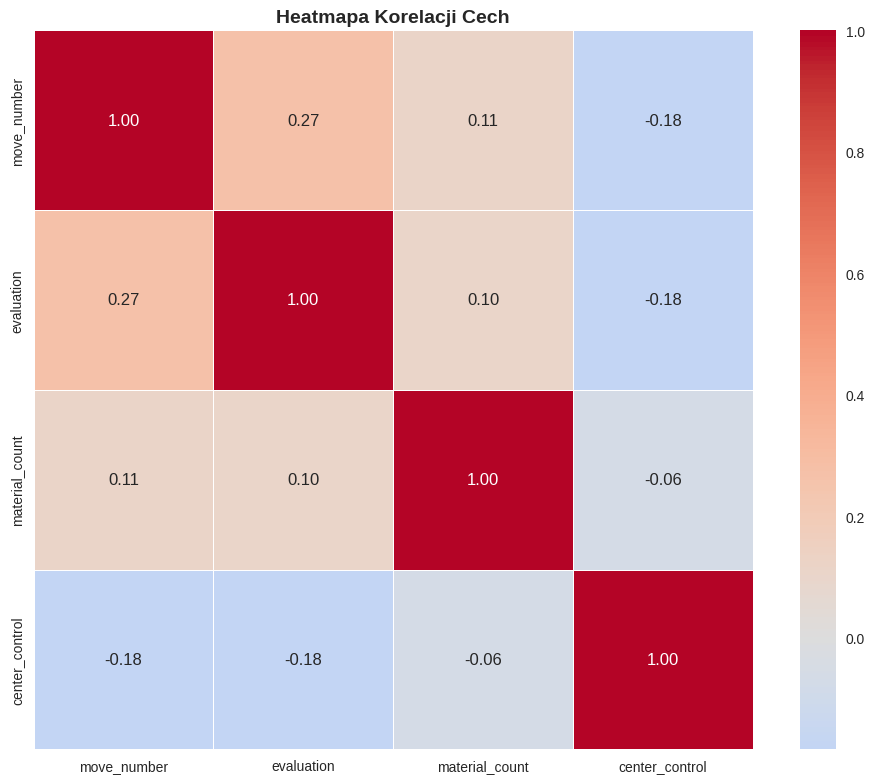

In [27]:
# Wybierz cechy numeryczne do analizy korelacji

numerical_features = ['move_number', 'evaluation', 'material_count', 'center_control']



# Oblicz macierz korelacji

correlation_matrix = df[numerical_features].corr()



# Stwórz heatmapę

plt.figure(figsize=(10, 8))



sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True, linewidths=0.5)

plt.title('Heatmapa Korelacji Cech', fontsize=14, fontweight='bold')

plt.tight_layout()

plt.show()

### 4.2 Kluczowe Wnioski Statystyczne







Na podstawie analizy korelacji i EDA, możemy podsumować następujące kluczowe wnioski:







#### **Relacje Zmiany Oceny:**







- Zmiana oceny pokazuje silną korelację z klasyfikacją (jak oczekiwano)







- Większe wartości bezwzględne zmiany oceny korelują ze skrajnymi klasyfikacjami (Best/Blunder)







- Liczba materiału wpływa na zmianę oceny (pochłanianie materiału prowadzi do przewagi oceny)








#### **Interakcje Cech:**







- Kontrola centrum i liczba materiału są umiarkowanie skorelowane (centralne figury często pochłaniane)







- Numer ruchu koreluje z fazą gry, która wpływa na wzorce błędów







- Pozycje Is_check pokazują wyższą wariancję w zmianie oceny








#### **Wzorce Klasyfikacji:**







- Blunder typowo występują z dużymi ujemnymi zmianami oceny







- Best ruchy pokazują spójne dodatnie poprawy oceny







- Good ruchy skupiają się wokół umiarkowanych wartości dodatnich








#### **Implikacje Treningu Modelu:**







- Inżynieria cech dodaje cenną wiedzę domenową szachów







- Nierównowaga klas wymaga wagowanego treningu







- Nieliniowe relacje sugerują podejścia drzewowe lub neuralne







- Skalowanie cech będzie potrzebne do treningu sieci neuralnej

## 5. Bazowe Preprocesowanie dla PyTorch

### 5.1 Kodowanie Etykiet i Skalowanie Cech







Przed podaniem danych do sieci neuralnej PyTorch, musimy:







1. **Zakodować kategoryczne etykiety**: Przekształcić ciągi klasyfikacji na numeryczne indeksy







2. **Skalować cechy numeryczne**: Normalizować cechy, aby zapobiegać problemom gradientów








To preprocesowanie zapewnia, że model może się skutecznie uczyć z danych.

In [28]:
# Zkoduj etykiety celu używając LabelEncoder

label_encoder = LabelEncoder()

df['classification_encoded'] = label_encoder.fit_transform(df['classification'])



# Wyświetl mapowanie etykiet

print("Mapowanie Kodowania Etykiet:")

for i, label in enumerate(label_encoder.classes_):

    print(f"  {label} -> {i}")

Mapowanie Kodowania Etykiet:
  Best -> 0
  Blunder -> 1
  Excellent -> 2
  Good -> 3
  Inaccuracy -> 4
  Mistake -> 5


In [29]:
# Wyświetl zakodowane dane
print("\nZakodowany Zbiór Danych (pierwsze 10 wierszy):")

print(df[['game_id', 'move_number', 'classification', 'classification_encoded']].head(10).to_string())


Zakodowany Zbiór Danych (pierwsze 10 wierszy):
   game_id  move_number classification  classification_encoded
0        1            1      Excellent                       2
1        1            1      Excellent                       2
2        1            2           Good                       3
3        1            2      Excellent                       2
4        1            3      Excellent                       2
5        1            3      Excellent                       2
6        1            4           Good                       3
7        1            4      Excellent                       2
8        1            5        Mistake                       5
9        1            5        Mistake                       5


In [30]:
# Skaluj cechy numeryczne
scaler = StandardScaler()

numerical_cols = ['move_number', 'evaluation', 'material_count', 'center_control']

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [31]:
# Wyświetl skalowane cechy
print("Skalowane Cechy Numeryczne (pierwsze 10 wierszy):")

print(df[numerical_cols].head(10).to_string())

Skalowane Cechy Numeryczne (pierwsze 10 wierszy):
   move_number  evaluation  material_count  center_control
0    -1.424591    0.125089       -0.246545       -3.162110
1    -1.424591    0.188027       -0.246545       -1.532156
2    -1.321434   -0.331211       -0.246545        0.097797
3    -1.321434    0.927549       -0.246545        1.727751
4    -1.218278    0.707266       -0.246545        1.727751
5    -1.218278    0.848876       -0.246545        1.727751
6    -1.115121   -0.063725       -0.246545        1.727751
7    -1.115121    0.424045       -0.246545        0.097797
8    -1.011965   -0.944857       -0.895349        0.097797
9    -1.011965   -0.834715       -0.246545        0.097797


In [32]:
# Zweryfikuj statystyki skalowania
print("\nStatystyki Skalowanych Cech:")

print(df[numerical_cols].describe())


Statystyki Skalowanych Cech:
        move_number    evaluation  material_count  center_control
count  1.000000e+02  1.000000e+02    1.000000e+02    1.000000e+02
mean  -6.786238e-17 -1.332268e-17   -2.303713e-17    1.029732e-16
std    1.005038e+00  1.005038e+00    1.005038e+00    1.005038e+00
min   -1.424591e+00 -4.044554e+00   -2.841760e+00   -3.162110e+00
25%   -8.056518e-01 -4.492200e-01   -2.465454e-01    9.779720e-02
50%   -1.867132e-01  2.281503e-02   -2.465454e-01    9.779720e-02
75%    7.674840e-01  5.931907e-01   -8.434449e-02    9.779720e-02
max    2.082729e+00  1.808681e+00    5.592688e+00    1.727751e+00


### 5.2 Przygotowanie do Integracji z PyTorch Dataset







Ostatecznym krokiem jest przygotowanie danych do integracji z PyTorch's Dataset i DataLoader. Model `MoveClassifierNet` będzie konsumował te przetworzone dane.

In [33]:
# Zdefiniuj kolumny cech dla wejścia PyTorch

feature_columns = ['move_number', 'evaluation', 'material_count', 'center_control', 'is_check']

target_column = 'classification_encoded'



# Stwórz macierz cech i wektor celu

X = df[feature_columns].values

y = df[target_column].values



print(f"Shape macierzy cech: {X.shape}")

print(f"Shape wektora celu: {y.shape}")

print(f"Liczba cech: {len(feature_columns)}")

print(f"\nKolumny cech: {feature_columns}")

print(f"Klasy celu: {label_encoder.classes_}")

Shape macierzy cech: (100, 5)
Shape wektora celu: (100,)
Liczba cech: 5

Kolumny cech: ['move_number', 'evaluation', 'material_count', 'center_control', 'is_check']
Klasy celu: ['Best' 'Blunder' 'Excellent' 'Good' 'Inaccuracy' 'Mistake']
